# Algoritmos de redución de dimensiones

Cuando no se tiene información experta sobre el proceso de clasificación, es usual extraer la mayor cantidad de "información" posible, lo cual se traduce en un alto número de características. Esto a su vez corresponde a un alto número de dimensiones en el espacio, lo cual origina varios problemas.

En primer lugar, es claro que la inclusión de arreglos de mayor dimensión aumenta la complejidad computacional tanto en tiempos de entrenamiento como en requerimientos de memoria.

En segundo lugar, encontramos la llamada "maldición de la dimensionalidad". Se ha considerado una paradoja porque sería de esperarse que a medida que aumenta la cantidad de información (número de dimensiones) el desempeño de los clasificadores, en lugar de aumentar, disminuye. La explicación radica en que cuando la dimensionalidad aumenta, el volumen del espacio **aumenta exponencialmente**, de manera que los datos disponibles se vuelven dispersos. Esta dispersión es problemática para cualquier método que esté basado en significancia estadística, es decir, la cantidad de datos necesarios para hacer una inferencia correcta también aumenta exponencialmente y por lo tanto las inferencias se vuelven débiles. Recordemos que el reconocimiento de patrones en general se soporta sobre una hipótesis de similitud por distancia: los datos cercanos en el espacio de características comparten propiedades en el mundo real. En un espacio de alta dimensionalidad, todos los datos aparecen dispersos y por lo tanto disímiles, lo que dificulta realizar asociaciones por similitud.

Existen entonces dos vertientes que buscan reducir dimensiones: selección de características y extracción (o generación) de características.

## Selección de características

La selección de características consiste en identificar variables que no contribuyen o incluso afectan el proceso de selección. Estas variables que no contribuyen a la separabilidad de las clases se denominan "no relevantes". Por el contario, las características que contribuyen a diferenciar entre clases se denominan "relevantes". 

Por ejemplo, si queremos que el computador aprenda a diferenciar hombres y mujeres, ¿sería útil incluir la edad o la nacionalidad?. ¿Qué tan útil sería incluir la altura de la persona o la longitud del cabello?

Por otro lado, dentro de las características relevantes, puede haber algunas que aporten información altamente correlacionada. Estas características se denominan "redundantes" y tampoco son deseables (no aportan información nueva pero sí aumentan la dimensionalidad).

Los algoritmos de selección de características se enfocan entonces en encontrar un subconjunto de características que sean relevantes y no redundantes. Necesitamos entonces definir un criterio que nos ayude a medir "qué tan bueno" es un determinado subconjunto de características y realizar una búsqueda dentro de todos los posibles subconjuntos. ¿Cuántos subconjuntos posibles habrá?

Ejemplo: Iris tiene 4 características. Todos los posibles subconjuntos serán:
1. $x_1$
2. $x_2$
3. $x_3$
4. $x_4$
5. $x_1, x_2$
6. $x_1, x_3$
7. $x_1, x_4$
8. $x_2, x_3$
9. $x_2, x_4$
10. $x_3, x_4$
11. $x_1, x_2, x_3$
12. $x_1, x_2, x_4$
13. $x_1, x_3, x_4$
14. $x_2, x_3, x_4$
15. $x_1, x_2, x_3, x_4$

En términos generales, para una base de datos con $n$ características, se tendrán $2^n - 1$ posibles subconjuntos. Dado que el número de subconjuntos crece exponencialmente, es inviable evaluarlos todos. Necesitamos usar alguna estrategia que nos permita encontrar el mejor subconjunto sin necesidad de revisar todas las posibilidades.

<img src="FStree.png" width=400/>

Si definimos una criterio de selección $J$ (que hace las veces de heurística), podemos entonces usar cualquier algoritmo de búsqueda informada sobre el grafo. Una implementación común es el uso de una estrategia voraz, que da origen al algoritmo conocido como selección sequencial hacia adelante (*sequential forward selection* - SFS):

1. Se empieza con el conjunto vacío de características seleccionadas y se inicializa $J_{best} = 0$.
2. Se añade cada una de las características pendientes por analizar al conjunto de características seleccionadas, y se evalúa el criterio de selección para cada uno de estos nuevos conjuntos.
3. Se escoge el conjunto que obtuvo el mejor criterio y se actualiza el conjunto de características seleccionadas así como $J_{best}$.
4. Se repiten los pasos 2 y 3 hasta que la inclusión de nuevas características no mejore el criterio.

Existen entonces dos tipos de criterio de selección: 

### 1) Métodos tipo filtro

Usan criterios de selección basados en medidas geométricas o estadísticas, que no implican el entrenamiento del clasificador. Los criterios más comunes se fundamentan en medidas de dispersión entre clases e intra-clase:

Supongamos que tenemos $C$ clases, cada una de ellas con $n_i$ muestras para $i \in 1\ldots C$. Si la matriz de covarianza de la i-ésima clase la definimos como $\boldsymbol{\Sigma}_i$ y su correspondiente media como $\boldsymbol{m}_i$, entonces podremos decir que la matriz de covarianza **entre clases** es:

\begin{equation}
S_B = \sum_{i=1}^C \frac{n_i}{n}(\boldsymbol{m}_i -\boldsymbol{m}) (\boldsymbol{m}_i -\boldsymbol{m})^T
\end{equation}

donde $n$ es el número total de muestras y $\boldsymbol{m}$ es la media total de toda la base de datos. A su vez, la matriz de covarianza **intra clases** será:

\begin{equation}
S_W = \sum_{i=1}^C \frac{n_i}{n}\Sigma_i
\end{equation}

La diagonal de $S_B$ nos da una medida *qué tan separadas son las clases entre sí* mientras que la diagonal de $S_W$ nos dice *qué tan compactas son las clases*. Como lo que queremos es seleccionar las características que nos estreguen clases compactas y separadas, algunos criterios de selección comúnmente usados son:

\begin{equation}
J_1= Tr(S_W+S_B)
\end{equation}

\begin{equation}
J_2= Tr(S_W^{-1}S_B)
\end{equation}

\begin{equation}
J_3= \frac{|S_W+S_B|}{|S_W|}
\end{equation}

\begin{equation}
J_4= \frac {Tr(S_B)}{Tr(S_W)}
\end{equation}

### 2) Métodos tipo *Wrapper*

Por otro lado, los métodos tipo *wrapper* usan directamente el clasificador como criterio de selección. Son por lo tanto más acertados, pero con mayor costo computacional ya que es necesario realizar algún tipo de validación para obtener la estimación de la utilidad.

\begin{equation}
J_5 = crossval(X,Y,classifier)
\end{equation}

La base de datos *wine* es el resultado de hacer el análsis químico de 178 vinos fabricados en la misma región de Italia, pero de tres diferentes variedades de cultivo. El análsis determinó las cantidades de 13 constituyentes encontrados en cada uno de los vinos:

1. Alcohol
2. Malic acid
3. Ash
4. Alcalinity of ash
5. Magnesium
6. Total phenols
7. Flavanoids
8. Nonflavanoid phenols
9. Proanthocyanins
10. Color intensity
11. Hue
12. OD280/OD315 of diluted wines
13. Proline 

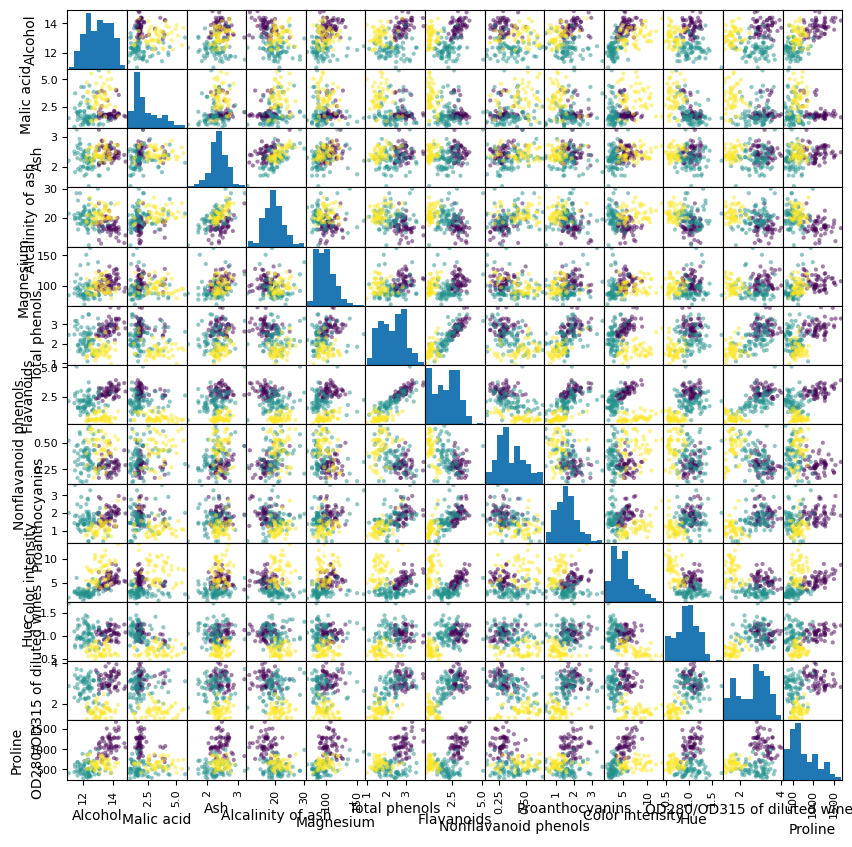

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets

# Importamos la base de datos wine
wine = datasets.load_wine()
X = wine.data  
y = wine.target
df=pd.DataFrame(X, columns=['Alcohol','Malic acid','Ash','Alcalinity of ash','Magnesium','Total phenols','Flavanoids','Nonflavanoid phenols','Proanthocyanins','Color intensity','Hue','OD280/OD315 of diluted wines','Proline' ])
plt.rcParams["figure.figsize"]=10,10 #Modifica el tamaño de la gráfica
axes = pd.plotting.scatter_matrix(df,c=y)
plt.show()

Apliquemos entonces la selección de características tipo filtro a ver qué pasa. Para hacer las pruebas vamos a usar un clasificador 10-NN.

In [3]:
#Primero vamos a definir una funcion para hacer validación cruzada

def knn_cv(X,y,k,folds):
    from sklearn.neighbors import KNeighborsClassifier    
    #Vector que asigna un fold a cada muestra
    f=np.tile(range(folds),np.floor(len(X)/folds).astype(int))
    sobrante=len(y)-len(f);
    f=np.append(f,range(sobrante))
    #Ciclo para recorrer los folds
    predicciones=np.zeros(len(y))
    for i in range(folds):
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(X[np.where(f!=i)], y[np.where(f!=i)]) #Se entrena con todos los folds menos el i
        test=np.array(X[np.where(f==i)]) #Prueba
        predicciones[np.where(f==i)]=clf.predict(test)
    acierto=predicciones==y
    return(sum(acierto)/len(y)) #Retorna el acierto del clasificador

#Veamos el resultado de clasificar usando todas las características:
acierto=knn_cv(X,y,10,10)
print(acierto)

0.6629213483146067


In [4]:

#Ahora implementamos el procedimiento de selección de características

def sfs(X,y,criterio):
    cond=0;
    Jbest=0;
    selection=[]; #Características seleccionadas
    available=range(len(X[0])); #Características disponibles
    while(cond==0):
        J=np.zeros(len(available)); #Ciclo que calcula el criterio al adicionar cada característica
        for i in range(len(available)):
            selectioni=np.append(selection,available[i])
            X_selec=X[:,selectioni.astype(int)];
#-------------------------------------------------------------------------------------------------
            media_total=np.asmatrix(np.mean(X_selec,axis=0)); #Media total
            clases=pd.DataFrame(X_selec).groupby(y)
            medias=np.array(clases.mean()); #Matriz con las medias de cada clase
            covarianzas=clases.cov();
            ni=clases.size(); #Número de muestras de cada clase
            SB=0
            SW=0
            for j in range(len(medias)):
                SB=SB+ni[j]/len(y)*(np.transpose(medias[j,:]-media_total).dot(medias[j,:]-media_total))
                Sigmai=covarianzas.loc[j]
                SW=SW+ni[j]/len(y)*(Sigmai)
#--------------------------------------------------------------------------------------------------
            if(criterio==1):
                J[i]=sum(np.diag(SB+SW))
            elif(criterio==2):
                J[i]=sum(np.diag(np.linalg.inv(SW).dot(SB)));
            elif(criterio==3):
                J[i]=np.linalg.det(SB+SW)/np.linalg.det(SW);
            elif(criterio==4):
                J[i]=sum(np.diag(SB))/sum(np.diag(SW))
            else:
                J[i]=knn_cv(X_selec,y,10,10);
#------------------------------------------------------------------------------------------------------
        mejor = np.argmax(J)
        if(J[mejor]>Jbest):
            Jbest=J[mejor]
            selection=np.append(selection,available[mejor])
            available=np.delete(available,mejor)
            if(available.size==0):
                cond=1
        else:
            cond=1
    return(selection)

seleccionadas=sfs(X,y,5)
print(seleccionadas)

[ 6.  0.  8. 10.]


In [5]:
#Veamos el resultado de clasificar con la selección hecha
acierto=knn_cv(X[:,seleccionadas.astype(int)],y,10,10)
print(acierto)

0.9438202247191011


# Generación de características: PCA

La generación de características busca, en lugar de escoger entre las características existentes, generar unas nuevas a partir de éstas. La forma más común es la generación lineal, en donde el método más usado es el análisis de componentes principales (PCA). 

PCA es una rotación del espacio de características para escoger las direcciones de mayor varianza. La matriz de rotación se escoge usando las direcciones de los principales eigenvectores de la matriz de covarianza (las direcciones de mayor variación de los datos) según un criterio de varianza acumulada. 

Veamos primero qué es una matriz de rotación:

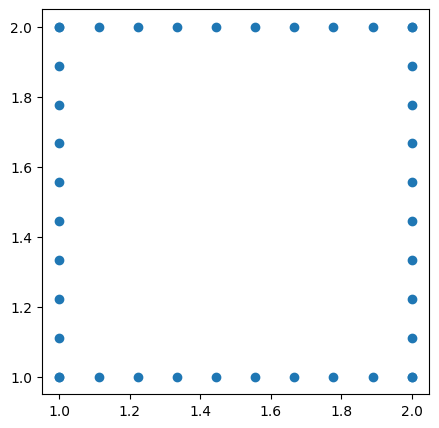

In [6]:
#Consideremos los puntos dados por las siguientes coordenadas

coordx=np.array([np.repeat(1,10),np.linspace(1,2,10),np.repeat(2,10),np.linspace(1,2,10)]).reshape(1,-1);
coordy=np.array([np.linspace(1,2,10),np.repeat(2,10),np.linspace(1,2,10),np.repeat(1,10)]).reshape(1,-1);
plt.rcParams["figure.figsize"]=5,5 #Modifica el tamaño de la gráfica
plt.scatter(coordx,coordy)
plt.show()


Ahora construyamos una matriz de rotación sencilla en dos dimensiones:

\begin{equation}
R=\left[ \begin{array}{cc}
            cos(\theta) & -sen(\theta)\\
            sen(\theta) & cos(\theta)\\
           \end{array} \right]
\end{equation}

Si, por ejemplo, hacemos $\theta = 45^\circ$, tendremos:

\begin{equation}
R=\left[ \begin{array}{cc}
            0.7071 & -0.7071\\
            0.7071 & 0.7071\\
           \end{array} \right]
\end{equation}

¿Qué pasa al multiplicar nuestros datos por R?
\begin{equation}
X_{rotados} = X^T R
\end{equation}


[[1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.11111111
  1.22222222 1.33333333 1.44444444 1.55555556 1.66666667 1.77777778
  1.88888889 2.         2.         2.         2.         2.
  2.         2.         2.         2.         2.         2.
  1.         1.11111111 1.22222222 1.33333333 1.44444444 1.55555556
  1.66666667 1.77777778 1.88888889 2.        ]
 [1.         1.11111111 1.22222222 1.33333333 1.44444444 1.55555556
  1.66666667 1.77777778 1.88888889 2.         2.         2.
  2.         2.         2.         2.         2.         2.
  2.         2.         1.         1.11111111 1.22222222 1.33333333
  1.44444444 1.55555556 1.66666667 1.77777778 1.88888889 2.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.        ]]
[[ 0.8660254 -0.5      ]
 [ 0.5        0.8660254]]


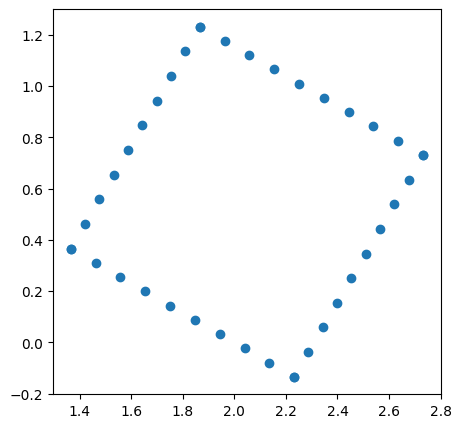

In [7]:
theta=np.pi/6
X=np.vstack([coordx,coordy])
print(X)
R=np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta),np.cos(theta)]])
print(R)
Xrotados=np.transpose(X).dot(R)
plt.scatter(Xrotados[:,0],Xrotados[:,1])
plt.show()


Consideremos ahora otro conjunto de datos en el que tenemos dos clases que queremos separar, pero primero queremos hacer una reducción de dimensiones:

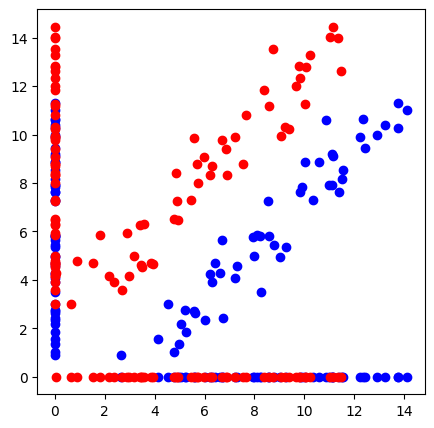

In [8]:
x=np.linspace(0,10,50)
clase1=np.array([x+3*np.random.uniform(size=50)+2,x+2*np.random.uniform(size=50)]).transpose()
clase2=np.array([x+2*np.random.uniform(size=50),x+3*np.random.uniform(size=50)+2]).transpose()

plt.rcParams["figure.figsize"]=5,5 #Modifica el tamaño de la gráfica

plt.scatter(clase1[:,0],np.repeat(0,len(x)),c='blue')
plt.scatter(clase2[:,0],np.repeat(0,len(x)),c='red')

plt.scatter(np.repeat(0,len(x)),clase1[:,1],c='blue')
plt.scatter(np.repeat(0,len(x)),clase2[:,1],c='red')

plt.scatter(clase1[:,0],clase1[:,1],c='blue')
plt.scatter(clase2[:,0],clase2[:,1],c='red')
plt.show()


Ninguna de las características que tenemos es suficiente para separar correctamente los datos. ¿Pero qué tal si rotamos los datos primero?

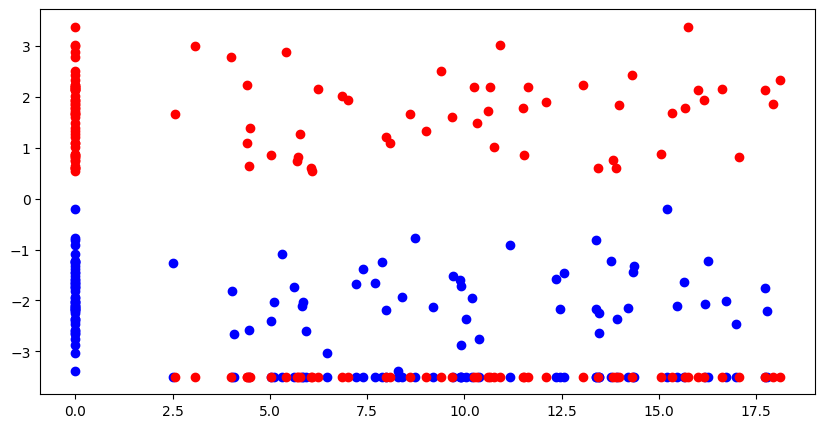

In [9]:
theta=np.pi/4
R=np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta),np.cos(theta)]])

clase1=(clase1).dot(R)
clase2=(clase2).dot(R)

plt.rcParams["figure.figsize"]=10,5 #Modifica el tamaño de la gráfica

plt.scatter(clase1[:,0],np.repeat(-3.5,len(x)),c='blue')
plt.scatter(clase2[:,0],np.repeat(-3.5,len(x)),c='red')

plt.scatter(np.repeat(0,len(x)),clase1[:,1],c='blue')
plt.scatter(np.repeat(0,len(x)),clase2[:,1],c='red')

plt.scatter(clase1[:,0],clase1[:,1],c='blue')
plt.scatter(clase2[:,0],clase2[:,1],c='red')
plt.show()

¡Ahora basta con una sola dimensión para separar correctamente los datos!

La idea con PCA es entonces, no sólo rotar los datos, sino también llevarlos a un espacio de menor dimensión en el que los datos se proyectan sobre las direcciones de máxima varianza. Esas direcciones de máxima varianza se encuentran como los vectores propios con más peso de la matriz de covarianza de los datos. Para esto, primero es necesario normalizar las variables con el fin de quitarles varianza debida a factores de escala. El procedimiento es entonces el siguiente:

1. Normalizar cada una de las características de la base de datos (se resta la media y se divide entre la desviación estándar)
2. Calcular la matriz de covarianza de los datos normalizados.
3. Calcular los vectores y valores propios de la matriz de covarianza.
4. Construir una matriz de rotación únicamente con los vectores propios más importantes.
5. Aplicar esta matriz de rotación a los datos originales.


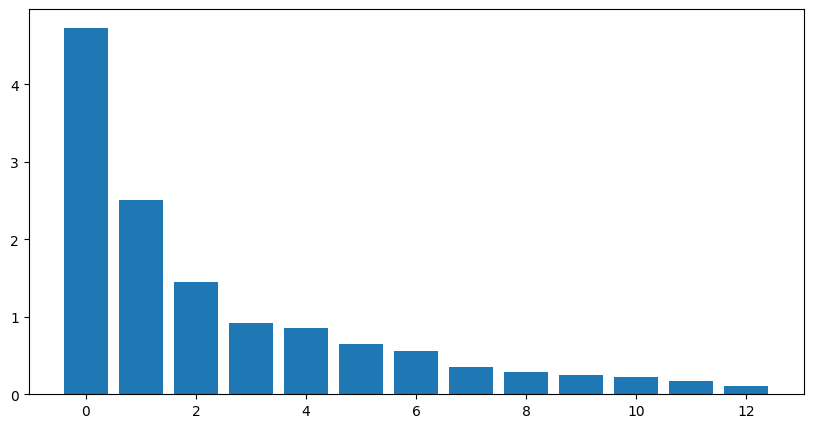

[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]
7


In [10]:
#Consideremos nuevamente la base de datos wine
wine = datasets.load_wine()
X = wine.data  
y = wine.target

#Normalización de los datos
mu=np.mean(X,axis=0)
sd=np.std(X,axis=0)
Xnorm=(X-mu)/sd

#Cálculo de la matriz de covarianza
Cov=np.cov(np.transpose(Xnorm))

#Cálculo de los valores y vectores propios
val,vec=np.linalg.eig(Cov)
plt.bar(range(len(val)),np.absolute(np.sort(-val)))
plt.show()

# #Varianza acumulada
va=np.cumsum(np.absolute(np.sort(-val)))/sum(val)
print(va)

# #Para quedarnos con el 90% de la varianza acumulada, debemos escoger 
limite=np.where(va>0.9)[0][0]
print(limite)

In [11]:
#Finalmente, construimos la matriz de rotación con los 7 primeros eigenvectores y se la aplicamos a los datos originales
R = vec[:,np.argsort(-val)[0:limite]]
Xpca=Xnorm.dot(R)
print(R.shape)
print(Xpca.shape)

(13, 7)
(178, 7)


In [12]:
#Veamos el resultado de clasificar con PCA
acierto=knn_cv(Xpca,y,10,10)
print(acierto)

0.9662921348314607
